# Algorithm

1. **Framewise visibility.** For each frame $t$, predict whether the vehicle is visible $\in\{0,1\}$.
2. **GoP-level position.** In each GoP, if the number of frames predicted visible $\ge F_{\min}$, estimate the position as the mean of the positions at the **first** and **last** detected frames in that GoP.

---

# Training

0. **Skip fillers.** If any frame has ground-truth FOV $=-1$ (experiment shorter than memory), skip that GoP. No backprop.
1. **Visibility loss.** For GoPs with ground-truth FOV $\in\{0,1\}$ at every frame, perform framewise binary classification and backprop using BCE.
2. **Position loss gating.**
   - If ground-truth visible frames in the GoP $\ge F_{\min}$:
     - Compute the position estimate (mean of first/last visible-frame positions).
     - Regress to the **ground-truth GoP position**, defined as the mean position over frames where GT visibility $=1$ in that GoP.
   - Else: no position loss or update.

---

# Inference

0. **Skip fillers.** Do not report metrics for GoPs containing GT FOV $-1$.
1. **Visibility metric.** For all valid GoPs, predict framewise visibility and report $0/1$ error.
2. **Position metric.** If predicted visible frames in a GoP $\ge F_{\min}$, output the position estimate and compute MSE vs the ground-truth GoP position (mean over GT-visible frames).
3. **GoP-level summary.**
   - **Required-but-missed:** GT visible $\ge F_{\min}$ but no position estimate produced.
   - **Spurious estimate:** GT visible $< F_{\min}$ but a position estimate was produced.
   - Report counts and ratios for both cases.

---

**Notes**
- $F_{\min}$: minimum visible-frame threshold to trigger position estimation and (during training) the position loss.
- For any time step, in order to say the vehicle is in the scene check if the estimated FoV probability is greater than $\tau$.
- FOV labels: $1$ visible, $0$ not visible, $-1$ filler.


In [1]:
# Import libraries

from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset
import torch
from torch.utils.data import DataLoader
import time 
from torchvision import transforms
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
from math import cos, pi
from torch.optim.lr_scheduler import LambdaLR
import os
import pickle
import math


In [2]:
# Base Transformer
class StateTransformer(nn.Module):
    def __init__(self, num_frames = 50, num_nodes = 4, embed_dim = 32, num_heads=4, depth=2, drop_prob=0.1):
        '''
            num_frames: Number of frames (packets, time steps) in the input
            num_nodes: number of gray nodes in the input
            embed_dim: hidden dimension of the transformer
            num_heads: number of heads in the transformer
            depth: depth of the transformer
            drop_prob: Dropout parameter for the transformer
        '''
        super(StateTransformer, self).__init__()

        self.num_frames = num_frames
        self.num_nodes = num_nodes
        self.hidden_dim = embed_dim
        
        self.packet_projector = nn.Linear(1, embed_dim)
        self.state_tok_projector = nn.Linear(embed_dim, embed_dim)
        
        # Position embedding for every packet/frame in the input
        self.frame_idx_embedding  = nn.Parameter(torch.empty(1, num_frames+1, embed_dim)) 
        # Embedding token for nodes
        self.node_idx_embeding  = nn.Parameter(torch.empty(1, num_nodes+1, embed_dim))

        # Normalize the state token 
        self.stateLN = nn.LayerNorm(embed_dim)
        
        # Initialize the tokens
        nn.init.trunc_normal_(self.frame_idx_embedding, std=0.02)
        nn.init.trunc_normal_(self.node_idx_embeding, std=0.02)
        
        # Encoder network
        self.transformer = nn.TransformerEncoder(nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=4*embed_dim, norm_first=False, batch_first=True, dropout=drop_prob), num_layers=depth)
        
    def forward(self, packet_input, state = None):
        # packet_input is of shape [B, N, T_eff] (Batch, Node Count, Number of frames)
        # state is of shape [B,D] (None at the beginning of video)
        
        # !!! If packet is 2D, (single batch) expand the tensor !!!
        if packet_input.ndim == 2:
            packet_input = packet_input.unsqueeze(0) 
            if state is not None:
                state = state.unsqueeze(0) 
        else:
            packet_input = packet_input
        
        B, N, T_eff = packet_input.shape
        
        packet_input = packet_input.reshape(B*N*T_eff,1)
        packet_input = packet_input.float() 
        packet_tok = self.packet_projector(packet_input) # output of shape [B*N*T_eff,D]
        packet_tok = packet_tok.reshape(B,N,T_eff,self.hidden_dim) # shape (B,N,T_eff,D)
        
        # Node embedding
        node_embed   = self.node_idx_embeding[0, 1:, :]  # [N,D]
        # Repeat for every batch and time step
        node_embed = node_embed.unsqueeze(0).unsqueeze(2) # (1, N, 1, D)
        node_embed = node_embed.repeat(B, 1, T_eff, 1) # (B, N, T_eff, D)
        
        # add node embedding
        packet_tok = packet_tok + node_embed
        
        # Frame index embedding
        frame_embed = self.frame_idx_embedding[0, 1:(T_eff+1), :]  # (T_eff, D)
        frame_embed = frame_embed.unsqueeze(0).unsqueeze(0)   # (1, 1, T_eff, D)
        frame_embed = frame_embed.repeat(B,N,1,1)           # (B, N, T_eff, D)
        
        # add frame (time step) embedding
        packet_tok = packet_tok + frame_embed
        
        # reshape the packet token to (B,N*T_eff,D)
        packet_tok = packet_tok.reshape(B,T_eff*N,self.hidden_dim)

        # Get the state token 
        if state is None:
            state_tok = torch.zeros(B, self.hidden_dim,
                                 dtype=packet_input.dtype, device=packet_input.device)
        else:
            state_tok = self.state_tok_projector(state)

        # Normalize and add embeddings
        state_tok = self.stateLN(state_tok)
        state_tok_embed = self.node_idx_embeding[0, 0, :] + self.frame_idx_embedding[0, 0, :] 
        state_tok = state_tok + ((state_tok_embed).repeat(B, 1))
        
        # append the state tokens on top of packet tokens for every sample in the batch
        transformer_input = torch.cat([state_tok.unsqueeze(1),packet_tok],dim=1)
        
        out = self.transformer(transformer_input) # input, output shape (B, (T_eff*N)+1, D) 
        out_gops = out[:,1:,:] # output for GOPs, shape (B,N*T_eff,D)
        out_state_tok = out[:,0,:] # (B,D)
                
        return out_state_tok # shape (B,W,D), (B,D)
        

In [3]:
class SimpleMLP(nn.Module):
    def __init__(self,input_dim = 40, hidden_dims = [256,128,64],output_dim = 2):
        super(SimpleMLP, self).__init__()

        layers = []
        
        # Add input layer
        layers.append(nn.Linear(input_dim, hidden_dims[0],bias=True))
        layers.append(nn.LayerNorm(hidden_dims[0]))
        layers.append(nn.GELU())

        # Add hidden layers dynamically
        for i in range(len(hidden_dims) - 1):
            layers.append(nn.Linear(hidden_dims[i], hidden_dims[i+1],bias=True))
            layers.append(nn.LayerNorm(hidden_dims[i+1]))
            layers.append(nn.GELU())

        # Use nn.ModuleList to register layers
        self.layers = nn.ModuleList(layers)

        # Layers for position and velocity estimation
        self.pos_layer = nn.Linear(hidden_dims[-1], output_dim, bias=True)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        
        out = self.pos_layer(x)
            
        return out

In [4]:
def lr_lambda(current_epoch: int):
    """
    Returns a multiplicative factor for the base LR of *each* param group.
    * Linear warm-up for the first `num_warmup_epoch` epochs.
    * Cosine decay to `final_lr_factor` thereafter.
    """
    if current_epoch < num_warmup_epoch:
        # warm-up from 0 → 1
        return float(current_epoch + 1) / float(num_warmup_epoch)

    # progress ∈ [0, 1] through the decay phase
    progress = (current_epoch - num_warmup_epoch) / float(epoch_count - num_warmup_epoch)
    cosine_component = 0.5 * (1 + cos(pi * progress))            # 1 → 0
    return final_lr_factor + (1 - final_lr_factor) * cosine_component

In [5]:
device = torch.device("cuda:1")

In [6]:
# Parameters
E = 1010 # Number of total videos
G = 47 # GOP per video
N = 4 # Number of nodes
T = 10 # GOP length

T_max = 470 # Max length of the input stream

T_in = 40 # Number of frames to the transformer
T_stride = 5 # Slide by how many frames for each 
N_out = 1 # Outputs per each window of W_in frames (always 1 here)
T_avg = 10 # Number frames to be used for ground truth FoV and pos generation

D = 128 # Hidden dimension of the transformer

# These parameters are for deciding whether a segment should have a position estimation or not
tau = 0.5 # p_hat threshold to say vehicle is in the FOV
T_min = T_avg*(tau) # Number of frames in a segment required for position estimation

In [7]:
# relative directory where the tensors are stored
# dataset_name = "bw10_delay0_jitter0_loss0"
# dataset_name = "bw10_delay20_jitter5_loss0"
dataset_name = "bw30_delay0_jitter0_loss0"
# dataset_name = "bw30_delay20_jitter5_loss0"
# dataset_name = "encrypted_delay20_jitter5_loss0"
# dataset_name = "unencrypted_delay20_jitter5_loss0"

# dataset_name = "bw50_delay0_jitter0_loss0"
# dataset_name = "bw50_delay20_jitter5_loss0"
# dataset_name = "bw100_delay0_jitter0_loss0"
# dataset_name = "bw100_delay20_jitter5_loss0"
# dataset_name = "bw1000_delay0_jitter0_loss0"
# dataset_name = "bw1000_delay20_jitter5_loss0"

main_dir = f"./tensors/seed1/{dataset_name}"
# main_dir = f"./tensors/seed1_timing/{dataset_name}"
# main_dir = "tensors/seed2/" # relative directory where the tensors are stored

# Import tensors 
# norm_frame_sizes = torch.load(os.path.join(main_dir, "normalized_frames_tensor.pt"), map_location=device) 

# norm_frame_sizes = torch.load("/home/zanoria/IoBT/gray_assets/zanoria/carla/grouping_packets/learning_method/checkpoints/bw10_delay0_jitter0_loss0/learned_grouped_tensor_normalized.pkl", 
#                                 map_location=device)
# norm_frame_sizes = torch.load("/home/zanoria/IoBT/gray_assets/zanoria/carla/grouping_packets/learning_method/checkpoints/bw100_delay0_jitter0_loss0/learned_grouped_tensor_normalized.pkl", 
#                                 map_location=device)
norm_frame_sizes = torch.load(f"/home/zanoria/IoBT/gray_assets/zanoria/carla/grouping_packets/learning_method/checkpoints/{dataset_name}/learned_grouped_tensor_normalized.pkl", 
                              map_location="cpu")


norm_frame_sizes = norm_frame_sizes[:,1:,:,:]

norm_position = torch.load(os.path.join(main_dir, "normalized_position_tensor.pt"), map_location=device) 
norm_velocity = torch.load(os.path.join(main_dir, "normalized_velocity_tensor.pt"), map_location=device) 

# (i,0) binary for whole sequence for visibility, for remaining j, it is camera index (i,j) 
# values: (0/1/2 = none/partial/full)
fov_values = torch.load(os.path.join(main_dir, "in_n_out_gt_tensor.pt"), map_location=device) # [E,5,G*T] 
fov_values = fov_values[:,:,10:]
# fov_values = torch.from_numpy(fov_values)
# [brand_id, color_id, yaw, vx, vy, x, y, rows]
meta_data_tensor = torch.load(os.path.join(main_dir, "meta_data_tensor.pt"), map_location=device) # [E,8]

# Reshape the tensors 
norm_frame_sizes = torch.reshape(norm_frame_sizes, (E,G,T,N)) # [E,G,T,N]
norm_position = torch.reshape(norm_position, (E,G,T,3)) # [E,G,T,3]
fov_values = torch.reshape(fov_values, (E,N+1,G,T)) # [E,G,2]

# Drop the first GoP
# norm_frame_sizes = norm_frame_sizes[:,1:,:,:]
# norm_position = norm_position[:,1:,:,:]
# fov_values = fov_values[:,:,1:,:]

E, G, T, N = norm_frame_sizes.shape

# 0/1 binary visibility for all cameras 1 if even one camera sees one vertex of the bounding box
fov_whole = fov_values[:,0,:,:] 

norm_frame_sizes = norm_frame_sizes.permute(0,3,1,2) # [E,N,G,T]
norm_frame_sizes = norm_frame_sizes.reshape(E,N,G*T) # [E,N,G*T]
norm_position = norm_position.reshape(E,G*T,3) # [E,G*T,3]
fov_whole = fov_whole.reshape(E,G*T) # [E,G*T]
# print(norm_position.shape)

In [8]:
# Shuffle data and sample train and test sets

# number of videos for training and validation data
E_train = 900
E_val = E - E_train

# Video indices for train and validation samples
# shuffle the indices between 0 and num_videos
torch.manual_seed(42)
shuffled_idx = torch.randperm(E)
# get the first num_train indices for training
val_idx = shuffled_idx[:E_val]                        # [E_train]
train_idx   = shuffled_idx[E_val:E_train + E_val]     # [E_val]
print(train_idx)
print(val_idx)

with open("train_idx.pkl", "wb") as f:
    pickle.dump(train_idx, f)

with open("val_idx.pkl", "wb") as f:
    pickle.dump(val_idx, f)

tensor([ 305,  691,  289,  341,  968,  569,  622,   85,  909,  425,  269,  615,
         163,  323,  172,   61,  603,   43,  443,  625,   14,  505,  842,  249,
         324,  493,   62,  714,  872,  931,  799,  127,  873,  499,  337,   90,
         796,  417,  658,  936,  732,  660,  920,  572,  934,  852,  690,  636,
         758,  623,   91,  412,  809,  432,  957,   28,  145,  364,  167,  698,
         705,  811,  870,  349,  757,  319,  562,  251,  101,  720,  558,  667,
         839,  348,  922,  186,  203,  976,  816,  226,   19,  385,  974,  462,
         179,  523,  829,  526,   27,  891,  216,   25,  712,  262,  531,  782,
         365,  407,  739,  173,  584,  483,   83,  312,  916,  320,  225,  400,
         481,  453,  458,  321,  343,  935,  195,  801,  510,  958,  480,  591,
         995,  157,  719,  683,   39,  755,  627,  244,  504,  992,  241,  594,
         845,  866,  744,  223,  426,  853,  214,  804,  165,  235, 1009,  939,
         954,  753,  276,  131,  553,  4

In [9]:
packet_tensor_train  = norm_frame_sizes[train_idx]             # [E_train, N, G*T]
packet_tensor_val    = norm_frame_sizes[val_idx]               # [E_val, N, G*T]

vel_tensor_train     = norm_velocity[train_idx,:2]                # [E_train, 2]
vel_tensor_val       = norm_velocity[val_idx,:2]                  # [E_val, 2]

pos_tensor_train = norm_position[train_idx, :, 0:2]  # [E_train, G*T, 2]
pos_tensor_val   = norm_position[val_idx,   :, 0:2]  # [E_val,   G*T, 2]

meta_tensor_train   = meta_data_tensor[train_idx]              # [E_train, 8]
meta_tensor_val      = meta_data_tensor[val_idx]           # [E_val, 8]

# just take the binary one for the whole sequence, ignore individual cameras
fov_tensor_train = fov_whole[train_idx] # [E_train,G*T]
fov_tensor_val = fov_whole[val_idx] # [E_val,G*T]

print(packet_tensor_train.shape)
print(packet_tensor_val.shape)

print(vel_tensor_train.shape)
print(vel_tensor_val.shape)

print(pos_tensor_train.shape)
print(pos_tensor_val.shape)

print(meta_tensor_train.shape)
print(meta_tensor_val.shape)

print(fov_tensor_train.shape)
print(fov_tensor_val.shape)

torch.Size([900, 4, 470])
torch.Size([110, 4, 470])
torch.Size([900, 2])
torch.Size([110, 2])
torch.Size([900, 470, 2])
torch.Size([110, 470, 2])
torch.Size([900, 8])
torch.Size([110, 8])
torch.Size([900, 470])
torch.Size([110, 470])


In [10]:
# declare models, parameters, optimizer, scheduler

# Hyper-parameters
# Transformer parameters
num_heads=4
depth=8
drop_prob=0.0

transformer_model = StateTransformer(num_frames = T_in, num_nodes = N, embed_dim = D, num_heads=num_heads, depth=depth, drop_prob=drop_prob)

# Predictor head parameters
input_dim = D
hidden_dims = [input_dim,input_dim//2,input_dim//4]
FOV_output_dim = 1
FOV_predictor_model = SimpleMLP(input_dim = input_dim, hidden_dims = hidden_dims, output_dim = FOV_output_dim)
pos_output_dim = 2
pos_predictor_model = SimpleMLP(input_dim = input_dim, hidden_dims = hidden_dims, output_dim = pos_output_dim)

num_params = sum(p.numel() for p in transformer_model.parameters() if p.requires_grad)
print(f"Total Transformer parameters: {num_params}")
print(transformer_model)

num_params = sum(p.numel() for p in FOV_predictor_model.parameters() if p.requires_grad)
print(f"Total FOV Predictor Head parameters: {num_params}")
print(FOV_predictor_model)

num_params = sum(p.numel() for p in pos_predictor_model.parameters() if p.requires_grad)
print(f"Total pos Predictor Head parameters: {num_params}")
print(pos_predictor_model)

transformer_model = transformer_model.to(device)
FOV_predictor_model = FOV_predictor_model.to(device)
pos_predictor_model = pos_predictor_model.to(device)

Total Transformer parameters: 1609088
StateTransformer(
  (packet_projector): Linear(in_features=1, out_features=128, bias=True)
  (state_tok_projector): Linear(in_features=128, out_features=128, bias=True)
  (stateLN): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-7): 8 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.0, inplace=False)
        (dropout2): Dropout(p=0.0, inplace=False)
      )
    )
  )
)
Total FOV Predi

In [11]:
# learning rate and weight decay
transformer_wd = 0.0
mlp_wd = 0.0

# transformer_lr = 1e-4
# mlp_lr = 5e-4

# Increased the learning rate because of the larger batch size
transformer_lr = 5e-4
mlp_lr = 1e-4

# batch_size = 30
batch_size = 180
epoch_count = 200
epoch_count = 500

num_warmup_epoch = 5    
final_lr_factor  = 0.01   

# Parameter for gradient flow over windows
detach_freq = 5 
# Weight for position estimation error in the loss function
pos_loss_weight = 1.0 

# Loss
criterion_FOV = nn.BCEWithLogitsLoss(reduction='none')
criterion_pos = nn.MSELoss(reduction='none')

optimizer = optim.Adam([
    {   # Transformer parameters
        "params": transformer_model.parameters(),
        "lr": transformer_lr,
        "weight_decay": transformer_wd,
    },

    {   # MLP parameters
        "params": FOV_predictor_model.parameters(),
        "lr": mlp_lr,
        "weight_decay": mlp_wd,
    },
    
    {   # MLP parameters
        "params": pos_predictor_model.parameters(),
        "lr": mlp_lr,
        "weight_decay": mlp_wd,
    },
    
])

scheduler = LambdaLR(optimizer, lr_lambda=lr_lambda, last_epoch=-1)

**Position stats** \
Mean: [-51.05060958862305, 22.786176681518555, 0.03074907697737217] \
Std : [20.354839324951172, 20.99863052368164, 0.06632454693317413] 

**Velocity stats** \
Mean: [-0.010638152249157429, 0.0681881383061409, -0.05335405841469765] \
Std : [8.109116554260254, 8.605400085449219, 0.09997598081827164]

In [12]:
# normalization stats for position
# pos_mean= [-51.05060958862305, 22.786176681518555]
# pos_std = [20.354839324951172, 20.99863052368164]
pos_mean = [-28.8091,  12.8157]
pos_std = [29.8735, 18.9070]
pos_err_std = 0.0

# denorm → add masked noise → renorm, keep [0,0] entries unchanged

device = pos_tensor_train.device
dtype  = pos_tensor_train.dtype

pos_mean_t = torch.as_tensor(pos_mean, dtype=dtype, device=device).view(1,1,2)
pos_std_t  = torch.as_tensor(pos_std,  dtype=dtype, device=device).view(1,1,2)

mask = (pos_tensor_train != 0).any(dim=-1, keepdim=True)   # [E,T,1]

pos_denorm = torch.where(
    mask, 
    pos_tensor_train * pos_std_t + pos_mean_t, 
    torch.zeros_like(pos_tensor_train)
)

# add Gaussian noise only where mask is True
noise = torch.randn_like(pos_denorm) * pos_err_std
pos_denorm_noisy = pos_denorm + (noise * mask)

# pos_denorm_noisy: [E,T,2]
dtype = pos_denorm_noisy.dtype
device = pos_denorm_noisy.device
eps = torch.finfo(dtype).eps

# valid rows are not exactly [0,0]
valid = (pos_denorm_noisy.abs().sum(dim=-1) > 0.0)        # [E,T]
if not valid.any():
    raise ValueError("No nonzero positions to compute stats.")

# stats over valid rows only
vals = pos_denorm_noisy[valid]                          # [M,2]
pos_mean_new = vals.mean(dim=0)                         # [2]
pos_std_new  = vals.std(dim=0, unbiased=False).clamp_min(eps)  # [2]

print(pos_mean_new)
print(pos_std_new)

norm = torch.zeros_like(pos_denorm_noisy)
norm[valid] = (pos_denorm_noisy[valid] - pos_mean_new) / pos_std_new

tensor([-28.7292,  12.8508], device='cuda:1')
tensor([29.8584, 18.8884], device='cuda:1')


In [13]:
# normalization stats for position
pos_mean= [-51.05060958862305, 22.786176681518555]
pos_std = [20.354839324951172, 20.99863052368164]

# Variables to keep track of FOV error per epoch
fov_inn_out_err_train = []
pos_est_fov_err_train = []
pos_est_mse_err_train = []

fov_inn_out_err_val = []
pos_est_fov_err_val = []
pos_est_mse_err_val = []

# move ground truth and  to the mps
pos_tensor_train = norm.to(device) # (E,T,2)
pos_tensor_val = pos_tensor_val.to(device)

packet_tensor_train = packet_tensor_train.to(device) # (E,N,T)
packet_tensor_val = packet_tensor_val.to(device)

fov_tensor_train = fov_tensor_train.to(device) # [E,T]
fov_tensor_val = fov_tensor_val.to(device)

meta_tensor_train = meta_tensor_train.to(device) # [E,8]
meta_tensor_val  = meta_tensor_val.to(device)

print(packet_tensor_train.shape)

torch.Size([900, 4, 470])


In [14]:
import math

VIS_MIN = int(T_min)  # at least half of T_avg are 1

history = {
    "train_fov": [],
    "val_fov": [],
    "train_pos": [],
    "val_pos": [],
    "val_pos_oracle": [],
}

for ep_idx in range(epoch_count):
    start_time = time.time()

    # train
    transformer_model.train()
    FOV_predictor_model.train()
    pos_predictor_model.train()  # position only in training

    running_fov_err_train = 0
    running_fov_count_train = 0
    running_pos_err_train = 0.0
    running_pos_count_train = 0

    shuffled_idx = torch.randperm(E_train)
    # num_batches = E_train // batch_size
    num_batches = math.ceil(E_train/batch_size)

    for b in range(num_batches):
        cur_idx = shuffled_idx[b * batch_size:batch_size * (b + 1)].to(device)

        eff_batch_size = min(batch_size, E_train - b*batch_size)

        prev_state = None
        optimizer.zero_grad()
        loss_total = None
        steps_accum = 0

        for first_idx in range(0, T_max - T_avg + 1, T_stride):
            # input
            input_packet = packet_tensor_train[cur_idx, :, first_idx:first_idx+T_in]  # [B,N,T_in]
            _, _, T_eff = input_packet.shape
            if T_eff < T_in:
                # tmp = torch.zeros(batch_size, N, T_in, device=input_packet.device, dtype=input_packet.dtype)
                tmp = torch.zeros(eff_batch_size, N, T_in, device=input_packet.device, dtype=input_packet.dtype)
                tmp[:, :, :T_eff] = input_packet
                input_packet = tmp

            # forward
            out_state_tok = transformer_model(input_packet, prev_state)      # (B,D)
            fov_logits = FOV_predictor_model(out_state_tok).squeeze(-1)     # (B)

            # GT FoV and masks
            gt_fov = fov_tensor_train[cur_idx, first_idx:first_idx+T_avg]   # (B,T_avg)
            valid = (gt_fov != -1)
            vis   = (gt_fov == 1) & valid
            invalid_frame_count = (~valid).sum(dim=1)                        # [B]
            mask_valid = invalid_frame_count < T_min                         # [B]
            num_valid = int(mask_valid.sum().item())

            valid_len = valid.sum(dim=1).clamp_min(1)                        # [B]
            ratio = vis.sum(dim=1).float() / valid_len.float()               # [B], in [0,1]

            # for metrics: binary visibility by "≥ half of T_avg are 1"
            true_visibility = (vis.sum(dim=1) >= VIS_MIN)                    # [B] bool

            fov_loss_per_step = torch.zeros((), device=device)
            pos_loss_per_step = torch.zeros((), device=device)

            if num_valid > 0:
                running_fov_count_train += num_valid

                # FoV loss vs ratio
                per_sample_fov = criterion_FOV(fov_logits, ratio.float())    # [B]
                fov_loss_per_step = per_sample_fov[mask_valid].mean()

                # FoV error metric vs binary target
                fov_est = (torch.sigmoid(fov_logits) >= tau)                 # [B]
                mismatched = (fov_est != true_visibility) & mask_valid
                running_fov_err_train += int(mismatched.sum().item())

                # Position loss only if "≥ half visible" AND valid
                pos_mask = mask_valid & true_visibility                      # [B]
                if pos_mask.any():
                    gt_pos = pos_tensor_train[cur_idx, first_idx:first_idx+T_avg]  # [B,T_avg,2]
                    m   = vis.unsqueeze(-1).to(gt_pos.dtype)                 # [B,T_avg,1]
                    cnt = vis.sum(dim=1, keepdim=True).clamp(min=1).to(gt_pos.dtype)  # [B,1]
                    avg_pos = (gt_pos * m).sum(dim=1) / cnt                  # [B,2]

                    preds_pos = pos_predictor_model(out_state_tok)           # [B,2]
                    # per-sample MSE → [B]
                    per_sample_pos = criterion_pos(preds_pos, avg_pos).mean(dim=1) if criterion_pos.reduction == 'none' else \
                                      torch.mean((preds_pos - avg_pos) ** 2, dim=1)
                    pos_loss_per_step = per_sample_pos[pos_mask].mean()

                    # L2 error metric
                    diff = (avg_pos - preds_pos)[pos_mask]                   # [B_eff,2]
                    running_pos_err_train += float(diff.norm(p=2, dim=1).sum().item())
                    running_pos_count_train += int(pos_mask.sum().item())

            # accumulate and detach-by-chunk
            step_loss = fov_loss_per_step + pos_loss_per_step
            loss_total = step_loss if loss_total is None else loss_total + step_loss
            steps_accum += 1

            if (steps_accum % detach_freq == 0) or (first_idx + T_stride >= T_max):
                if (loss_total is not None) and loss_total.requires_grad:
                    (loss_total / steps_accum).backward()
                    optimizer.step()
                    optimizer.zero_grad(set_to_none=True)
                loss_total = None
                steps_accum = 0
                prev_state = out_state_tok.detach()
            else:
                prev_state = out_state_tok

    avg_fov_err_train = running_fov_err_train / max(1, running_fov_count_train)
    avg_pos_err_train = running_pos_err_train / max(1, running_pos_count_train) if running_pos_count_train > 0 else 0.0
    scheduler.step()

    # validation (FoV + position)
    transformer_model.eval()
    FOV_predictor_model.eval()
    pos_predictor_model.eval()
    
    running_fov_err_val = 0
    running_fov_count_val = 0
    running_pos_err_val = 0.0
    running_pos_count_val = 0
    # ORACLE metrics
    running_pos_err_val_orc = 0.0
    running_pos_count_val_orc = 0
    
    with torch.no_grad():
        # num_val_batches = E_val // batch_size
        num_val_batches = math.ceil(E_val/batch_size)
        
        shuffled_idx = torch.randperm(E_val)
    
        for b in range(num_val_batches):
            cur_idx = shuffled_idx[b * batch_size:batch_size * (b + 1)].to(device)
            prev_state = None

            eff_batch_size = min(batch_size, E_val - b*batch_size)

            for first_idx in range(0, T_max - T_avg + 1, T_stride):
                input_packet = packet_tensor_val[cur_idx, :, first_idx:first_idx+T_in]
                _, _, T_eff = input_packet.shape
                if T_eff < T_in:
                    # tmp = torch.zeros(batch_size, N, T_in, device=input_packet.device, dtype=input_packet.dtype)
                    tmp = torch.zeros(eff_batch_size, N, T_in, device=input_packet.device, dtype=input_packet.dtype)
                    tmp[:, :, :T_eff] = input_packet
                    input_packet = tmp
    
                out_state_tok = transformer_model(input_packet, prev_state)
                fov_logits = FOV_predictor_model(out_state_tok).squeeze(-1)
                fov_probs  = torch.sigmoid(fov_logits)
    
                gt_fov = fov_tensor_val[cur_idx, first_idx:first_idx+T_avg]
                valid = (gt_fov != -1)
                vis   = (gt_fov == 1) & valid
                invalid_frame_count = (~valid).sum(dim=1)
                mask_valid = invalid_frame_count < T_min
                num_valid = int(mask_valid.sum().item())
                if num_valid > 0:
                    running_fov_count_val += num_valid
                    true_visibility = (vis.sum(dim=1) >= VIS_MIN)
                    fov_est = (fov_probs >= tau)
                    mismatched = (fov_est != true_visibility) & mask_valid
                    running_fov_err_val += int(mismatched.sum().item())
    
                    # Predicted-gated position metric: avg over ALL T_avg (no masking)
                    pos_mask_pred = fov_est & mask_valid
                    if pos_mask_pred.any():
                        gt_pos  = pos_tensor_val[cur_idx, first_idx:first_idx+T_avg]    # [B,T_avg,2]
                        avg_pos = gt_pos.mean(dim=1)                                    # [B,2]
                        preds_pos = pos_predictor_model(out_state_tok)                  # [B,2]
                        diff = (avg_pos - preds_pos)[pos_mask_pred]                     # [B_eff,2]
                        running_pos_err_val   += float(diff.norm(p=2, dim=1).sum().item())
                        running_pos_count_val += int(pos_mask_pred.sum().item())
    
                    # ORACLE-masked position metric: gate by GT, avg over visible frames only
                    pos_mask_orc = mask_valid & true_visibility
                    if pos_mask_orc.any():
                        gt_pos = pos_tensor_val[cur_idx, first_idx:first_idx+T_avg]     # [B,T_avg,2]
                        m   = vis.unsqueeze(-1).to(gt_pos.dtype)                        # [B,T_avg,1]
                        cnt = vis.sum(dim=1, keepdim=True).clamp(min=1).to(gt_pos.dtype)# [B,1]
                        avg_pos_orc = (gt_pos * m).sum(dim=1) / cnt                     # [B,2]
                        preds_pos = pos_predictor_model(out_state_tok)                  # [B,2]
                        diff_orc = (avg_pos_orc - preds_pos)[pos_mask_orc]              # [B_eff,2]
                        running_pos_err_val_orc   += float(diff_orc.norm(p=2, dim=1).sum().item())
                        running_pos_count_val_orc += int(pos_mask_orc.sum().item())
    
                prev_state = out_state_tok.detach()
    
    avg_fov_err_val = running_fov_err_val / max(1, running_fov_count_val)
    avg_pos_err_val = running_pos_err_val / max(1, running_pos_count_val) if running_pos_count_val > 0 else 0.0
    avg_pos_err_val_orc = running_pos_err_val_orc / max(1, running_pos_count_val_orc) if running_pos_count_val_orc > 0 else 0.0
    
    print(f"[epoch {ep_idx+1}/{epoch_count}] "
          f"train_fov_err={avg_fov_err_train:.6f} | train_pos_l2={avg_pos_err_train:.6f} | "
          f"val_fov_err={avg_fov_err_val:.6f} | val_pos_l2={avg_pos_err_val:.6f} | "
          f"val_pos_l2_oracle={avg_pos_err_val_orc:.6f}")

    
    history["train_fov"].append(avg_fov_err_train)
    history["val_fov"].append(avg_fov_err_val)
    history["train_pos"].append(avg_pos_err_train)
    history["val_pos"].append(avg_pos_err_val)
    history["val_pos_oracle"].append(avg_pos_err_val_orc)


[epoch 1/500] train_fov_err=0.261070 | train_pos_l2=0.817922 | val_fov_err=0.148125 | val_pos_l2=0.927226 | val_pos_l2_oracle=0.808256
[epoch 2/500] train_fov_err=0.204581 | train_pos_l2=0.808140 | val_fov_err=0.603797 | val_pos_l2=0.745506 | val_pos_l2_oracle=1.041589
[epoch 3/500] train_fov_err=0.203225 | train_pos_l2=0.811201 | val_fov_err=0.178374 | val_pos_l2=1.015145 | val_pos_l2_oracle=0.791011
[epoch 4/500] train_fov_err=0.197011 | train_pos_l2=0.803365 | val_fov_err=0.161054 | val_pos_l2=0.942318 | val_pos_l2_oracle=0.787728
[epoch 5/500] train_fov_err=0.197143 | train_pos_l2=0.800531 | val_fov_err=0.440355 | val_pos_l2=0.826080 | val_pos_l2_oracle=0.783723
[epoch 6/500] train_fov_err=0.182856 | train_pos_l2=0.795048 | val_fov_err=0.136267 | val_pos_l2=0.945464 | val_pos_l2_oracle=0.796932
[epoch 7/500] train_fov_err=0.156515 | train_pos_l2=0.796738 | val_fov_err=0.254177 | val_pos_l2=0.659976 | val_pos_l2_oracle=0.818969
[epoch 8/500] train_fov_err=0.153802 | train_pos_l2=0.7

KeyboardInterrupt: 

In [15]:
print(len(history["val_pos_oracle"]))

292


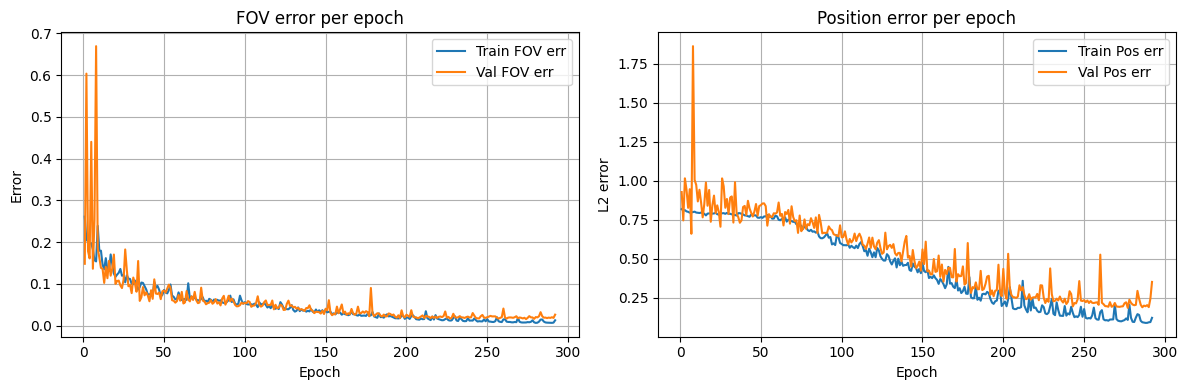

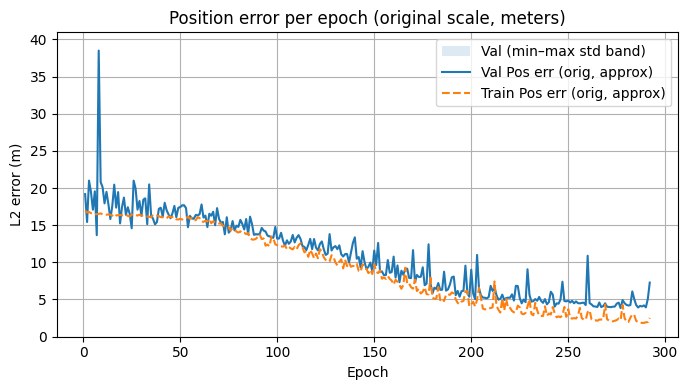

Saved to /home/zanoria/IoBT/gray_assets/zanoria/carla/grouping_packets/saved_plots/seed1_newnb/bw30_delay0_jitter0_loss0


In [16]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

epochs = np.arange(1, len(history["train_fov"]) + 1)

# --- Figure 1: Errors (FOV & Position) ---
fig1, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
axes[0].plot(epochs, history["train_fov"], label="Train FOV err")
axes[0].plot(epochs, history["val_fov"],   label="Val FOV err")
axes[0].set_title("FOV error per epoch")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Error"); axes[0].grid(True); axes[0].legend()

axes[1].plot(epochs, history["train_pos"], label="Train Pos err")
axes[1].plot(epochs, history["val_pos"],   label="Val Pos err")
axes[1].set_title("Position error per epoch")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("L2 error"); axes[1].grid(True); axes[1].legend()

fig1.tight_layout()

# --- Figure 2: A/B ratios (each subplot shows train vs val) ---
# fig2, axes2 = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
# pairs = [
#     ("A1A_train", "A1A_val", "A1/A (must & DID)"),
#     ("A2A_train", "A2A_val", "A2/A (must & DID NOT)"),
#     ("B1B_train", "B1B_val", "B1/B (must NOT & DID)"),
#     ("B2B_train", "B2B_val", "B2/B (must NOT & DID NOT)"),
# ]
# for ax, (k_tr, k_va, title) in zip(axes2.ravel(), pairs):
#     ax.plot(epochs, history[k_tr], label="train")
#     ax.plot(epochs, history[k_va], label="val")
#     ax.set_title(title); ax.set_xlabel("Epoch"); ax.set_ylabel("Ratio")
#     ax.set_ylim(0.0, 1.0); ax.grid(True); ax.legend()

# fig2.tight_layout()

# --- Figure 3: De-normalized (original-scale) position error (meters) ---
# --- De-normalized (original-scale) position error from stats ---
# pos_mean not needed for distances; only stds matter.
std_x, std_y = float(pos_std[0]), float(pos_std[1])

# Isotropic approximation factor: E[||diag(std) * e'||] ~ ||e'|| * sqrt((sx^2 + sy^2)/2)
scale_iso = np.sqrt(std_x**2 + std_y**2) / np.sqrt(2.0)

train_pos_norm = np.asarray(history["train_pos"], dtype=float)
val_pos_norm   = np.asarray(history["val_pos"], dtype=float)

train_pos_orig_approx = train_pos_norm * scale_iso
val_pos_orig_approx   = val_pos_norm   * scale_iso

# Conservative bounds (if all error aligned with one axis)
s_min, s_max = min(std_x, std_y), max(std_x, std_y)
train_lower, train_upper = train_pos_norm * s_min, train_pos_norm * s_max
val_lower,   val_upper   = val_pos_norm   * s_min, val_pos_norm   * s_max

# Plot
fig3, ax3 = plt.subplots(1, 1, figsize=(7, 4))
ax3.fill_between(epochs, val_lower, val_upper, alpha=0.15, label="Val (min–max std band)")
ax3.plot(epochs, val_pos_orig_approx,   label="Val Pos err (orig, approx)")
ax3.plot(epochs, train_pos_orig_approx, label="Train Pos err (orig, approx)", linestyle="--")
ax3.set_title("Position error per epoch (original scale, meters)")
ax3.set_xlabel("Epoch"); ax3.set_ylabel("L2 error (m)")
ax3.grid(True); ax3.legend()
fig3.tight_layout()


# (optional) save
outdir = Path(f"./saved_plots/seed1_newnb/{dataset_name}"); outdir.mkdir(parents=True, exist_ok=True)
fig1.savefig(outdir / "errors.png", dpi=150)
# fig2.savefig(outdir / "ratios.png", dpi=150)
fig3.savefig(outdir / "pos_error_denorm_from_stats.png", dpi=150)

plt.show()
print(f"Saved to {outdir.resolve()}")

**Count gops** \
A. That must have a position estimation (Ground truth fov contains at least fov_min 1's) \
    A1. That did get a position estimation \ (estimated probs >= tau exceed fov_min)
    A2. That did not get a position estimation \ (estimated probs >= tau less than fov_min)
B. That must NOT have a position estimation (Ground truth fov does not contain at least fov_min 1's) \
    B1. That did get a position estimation \ (estimated probs >= tau exceed fov_min)
    B2. That did not get a position estimation  (estimated probs >= tau less than fov_min)

In [17]:
# =======================================================
# ===== END OF TRAINING LOOP and FINAL PRINT STATEMENTS =====
# =======================================================


## NEW: Save the final trained models
print("\nTraining finished. Saving models...")

# Create a directory to save the models if it doesn't exist
save_dir = f"./saved_models/seed1_learned/{dataset_name}"
os.makedirs(save_dir, exist_ok=True)

def sd(m):  # handles DataParallel/DDP
    return m.module.state_dict() if hasattr(m, "module") else m.state_dict()

torch.save(sd(transformer_model),     f"{save_dir}/transformer.pt")
torch.save(sd(FOV_predictor_model),   f"{save_dir}/fov_head.pt")
torch.save(sd(pos_predictor_model),   f"{save_dir}/pos_head.pt")



Training finished. Saving models...


In [18]:
foo1 = torch.load("tensors/seed1_timing/bw30_delay0_jitter0_loss0/normalized_packets_tensor.pt")
foo2 = torch.load("tensors/seed1/bw30_delay0_jitter0_loss0/normalized_packets_tensor.pt")

print(torch.sum(foo1 == foo2))
print(foo1.flatten().shape)

tensor(849026)
torch.Size([1898800])
